<a href="https://colab.research.google.com/github/asad-iqbal78/ai-internship/blob/main/week6_anpr_detection_ocr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 6 — Automatic Number Plate Recognition (ANPR)

## Objective

The goal of this project is to build a basic Automatic Number Plate Recognition (ANPR) pipeline.

The system takes a vehicle image, detects the license plate using YOLO, crops the detected plate region, and then uses EasyOCR to recognize the characters written on the plate.

## Pipeline

Vehicle Image → License Plate Detection → Plate Cropping → OCR → Plate Text

## Technologies Used

* Python
* Google Colab
* YOLO
* Ultralytics
* EasyOCR
* OpenCV
* OpenCV / Computer Vision
* Matplotlib

## Expected Output

The system should:

1. Detect a license plate in a vehicle image.
2. Extract the detected plate region.
3. Read the characters using OCR.
4. Return the detected text along with OCR confidence.

## Important Note

OCR accuracy depends on image quality, resolution, lighting, viewing angle, and the visibility of the license plate. Low-confidence OCR results should not be treated as confirmed plate numbers.


In [1]:
!pip install ultralytics easyocr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 115.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 972.1/972.1 kB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 27.6 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO

print("YOLO installed successfully!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
YOLO installed successfully!


In [3]:
import easyocr

reader = easyocr.Reader(['en'])

print("EasyOCR installed successfully!")

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteEasyOCR installed successfully!


In [4]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

print("YOLO model loaded successfully!")

YOLO model loaded successfully!



image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 11.3ms
Speed: 85.5ms preprocess, 11.3ms inference, 40.8ms postprocess per image at shape (1, 3, 640, 480)


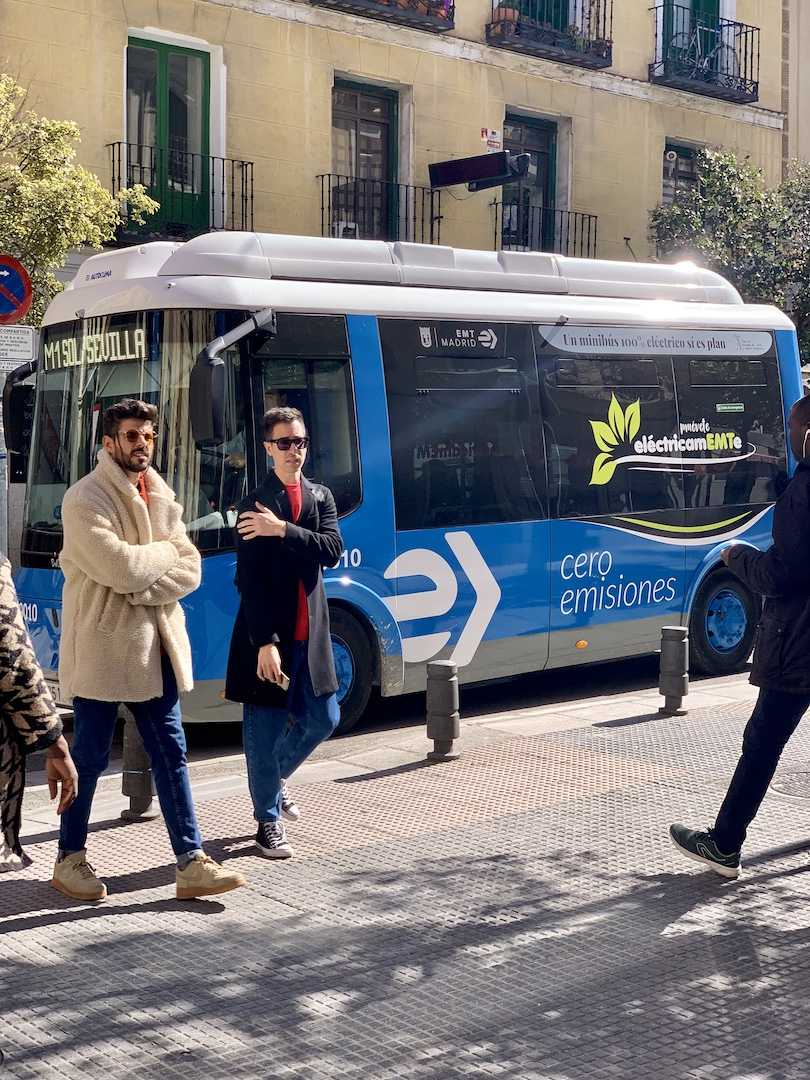

In [5]:
from PIL import Image
from IPython.display import display

results = model("https://ultralytics.com/images/bus.jpg")

display(Image.open("bus.jpg"))

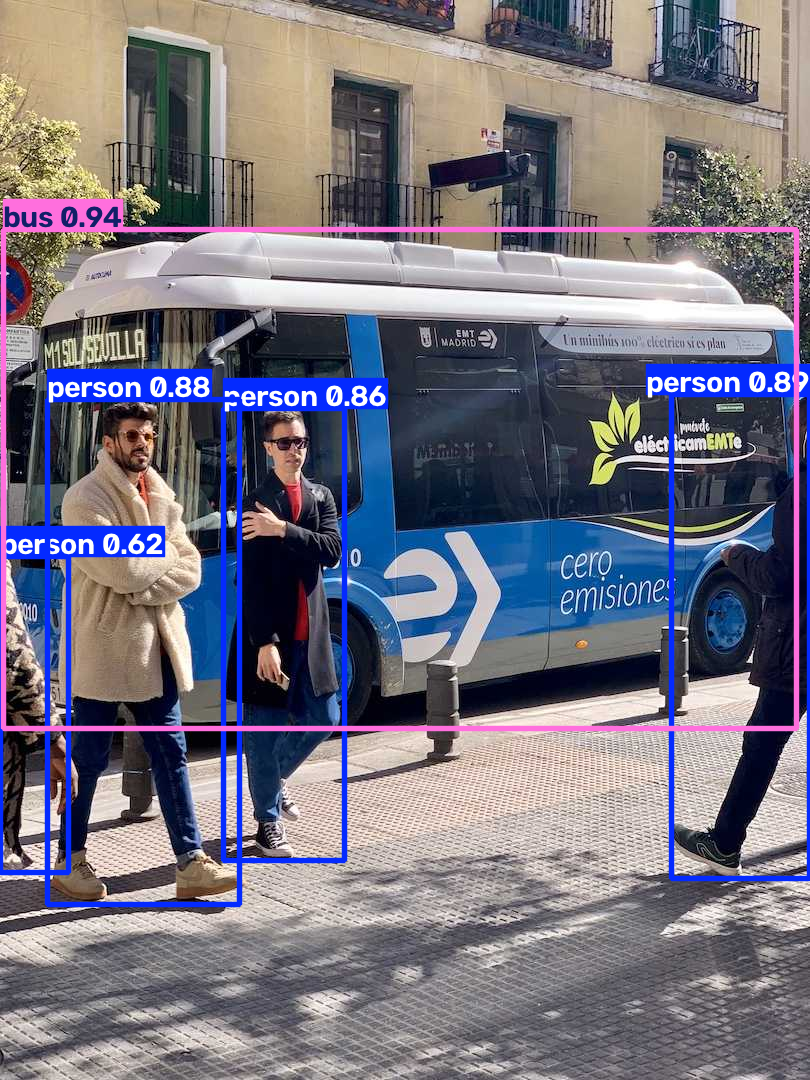

In [6]:
results[0].show()

In [8]:
from huggingface_hub import hf_hub_download
from ultralytics import YOLO

model_path = hf_hub_download(
    repo_id="joker5914/yolov8n-license-plate",
    filename="best.pt"
)

plate_model = YOLO(model_path)

print("License plate model loaded successfully!")

best.pt: reconstructing file:   0%|          |  0.00B / 6.24MB            

best.pt: downloading bytes:           |  0.00B            

License plate model loaded successfully!


In [9]:
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

print("Image:", image_path)

Saving car1.jfif to car1.jfif
Image: car1.jfif


In [11]:
from PIL import Image

img = Image.open(image_path)
img = img.convert("RGB")

new_path = "car1.jpg"
img.save(new_path, "JPEG")

print("Converted:", new_path)

Converted: car1.jpg


Saving car1.jfif to car1 (1).jfif
Uploaded: car1 (1).jfif
Converted successfully: /content/car1.jpg

image 1/1 /content/car1.jpg: 352x640 1 license_plate, 5.7ms
Speed: 2.3ms preprocess, 5.7ms inference, 1.4ms postprocess per image at shape (1, 3, 352, 640)


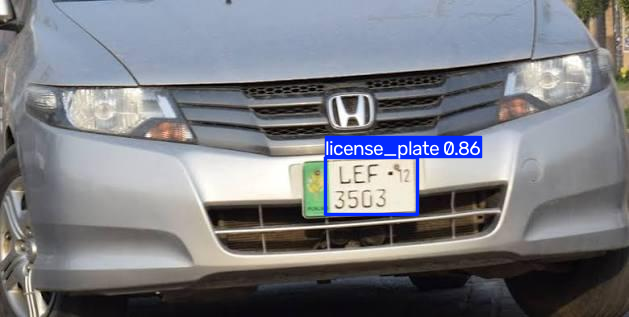

In [13]:
from PIL import Image
from google.colab import files

uploaded = files.upload()

original_path = list(uploaded.keys())[0]

print("Uploaded:", original_path)

img = Image.open(original_path).convert("RGB")
image_path = "/content/car1.jpg"
img.save(image_path, "JPEG")

print("Converted successfully:", image_path)

results = plate_model(image_path)

results[0].show()

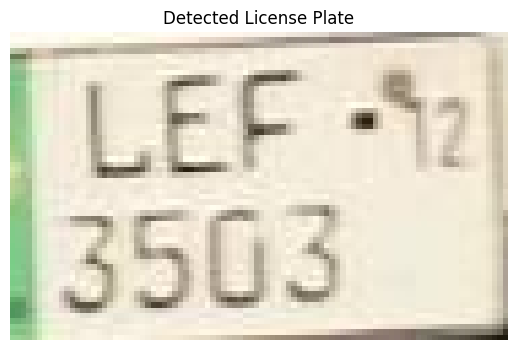

In [14]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread(image_path)

box = results[0].boxes.xyxy[0].cpu().numpy()

x1, y1, x2, y2 = map(int, box)

plate_crop = image[y1:y2, x1:x2]

plate_crop_rgb = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 4))
plt.imshow(plate_crop_rgb)
plt.axis("off")
plt.title("Detected License Plate")
plt.show()

In [15]:
ocr_result = reader.readtext(plate_crop_rgb)

print("OCR Result:")
print(ocr_result)

OCR Result:
[([[np.int32(10), np.int32(4)], [np.int32(58), np.int32(4)], [np.int32(58), np.int32(30)], [np.int32(10), np.int32(30)]], 'LEF', np.float64(0.8710978580391184)), ([[np.int32(6), np.int32(28)], [np.int32(66), np.int32(28)], [np.int32(66), 57], [np.int32(6), 57]], '3503', np.float64(0.834913432598114))]


In [16]:
if ocr_result:
    plate_text = ocr_result[0][1]
    confidence = ocr_result[0][2]

    print("Detected Plate:", plate_text)
    print("OCR Confidence:", round(confidence, 2))
else:
    print("No text detected")

Detected Plate: LEF
OCR Confidence: 0.87


In [17]:
plate_parts = []

for result in ocr_result:
    text = result[1]
    confidence = float(result[2])

    if confidence >= 0.50:
        plate_parts.append(text)

plate_text = " ".join(plate_parts)

print("Final Detected Plate:", plate_text)

Final Detected Plate: LEF 3503


In [18]:
def detect_plate(image_path):
    # YOLO plate detection
    results = plate_model(image_path)

    if len(results[0].boxes) == 0:
        return None

    # Original image
    image = cv2.imread(image_path)

    # First detected plate
    box = results[0].boxes.xyxy[0].cpu().numpy()
    x1, y1, x2, y2 = map(int, box)

    # Crop plate
    plate_crop = image[y1:y2, x1:x2]

    # Convert to RGB
    plate_rgb = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2RGB)

    # OCR
    ocr_result = reader.readtext(plate_rgb)

    if not ocr_result:
        return None

    # Keep reasonably confident text
    parts = []

    for result in ocr_result:
        text = result[1]
        confidence = float(result[2])

        if confidence >= 0.50:
            parts.append(text)

    plate_text = " ".join(parts)

    return {
        "plate": plate_text,
        "confidence": max(float(r[2]) for r in ocr_result),
        "crop": plate_rgb
    }

In [19]:
result = detect_plate(image_path)

if result:
    print("Detected Plate:", result["plate"])
    print("Confidence:", round(result["confidence"], 2))
else:
    print("No license plate detected.")


image 1/1 /content/car1.jpg: 352x640 1 license_plate, 8.7ms
Speed: 3.6ms preprocess, 8.7ms inference, 2.0ms postprocess per image at shape (1, 3, 352, 640)
Detected Plate: LEF 3503
Confidence: 0.87


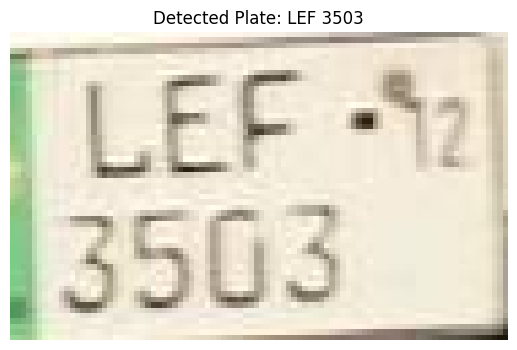

In [20]:
plt.figure(figsize=(10, 4))
plt.imshow(result["crop"])
plt.axis("off")
plt.title(f"Detected Plate: {result['plate']}")
plt.show()

Saving car1.jfif to car1 (2).jfif
Saving car2.jfif to car2 (1).jfif
Saving car3.jfif to car3.jfif
Saving car4.jfif to car4.jfif
Saving car5.jfif to car5.jfif

Image: car1 (2).jfif

image 1/1 /content/test_car.jpg: 352x640 1 license_plate, 8.1ms
Speed: 1.8ms preprocess, 8.1ms inference, 1.4ms postprocess per image at shape (1, 3, 352, 640)
Detected Plate: LEF 3503
Confidence: 0.87


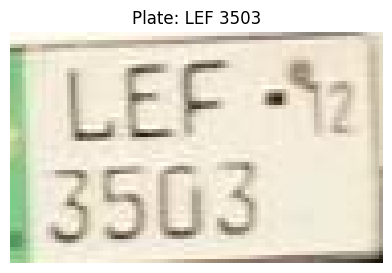


Image: car2 (1).jfif

image 1/1 /content/test_car.jpg: 448x640 1 license_plate, 7.1ms
Speed: 1.5ms preprocess, 7.1ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)
Detected Plate: 
Confidence: 0.0


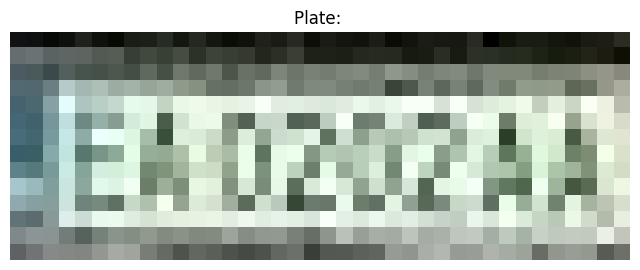


Image: car3.jfif

image 1/1 /content/test_car.jpg: 512x640 1 license_plate, 38.7ms
Speed: 1.9ms preprocess, 38.7ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 640)
Detected Plate: 06 572
Confidence: 1.0


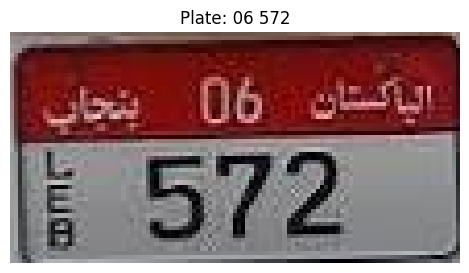


Image: car4.jfif

image 1/1 /content/test_car.jpg: 384x640 1 license_plate, 39.2ms
Speed: 1.4ms preprocess, 39.2ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
Detected Plate: 
Confidence: 0.31


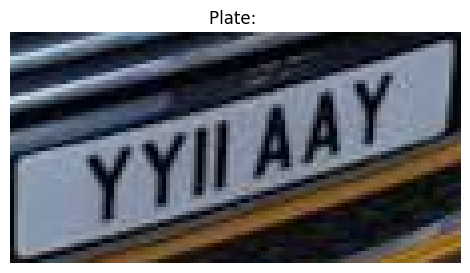


Image: car5.jfif

image 1/1 /content/test_car.jpg: 512x640 1 license_plate, 7.6ms
Speed: 4.3ms preprocess, 7.6ms inference, 1.4ms postprocess per image at shape (1, 3, 512, 640)
Detected Plate: 
Confidence: 0.3


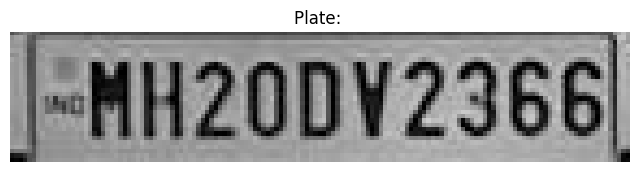

In [22]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    print("\n==============================")
    print("Image:", filename)

    # Convert image to JPG
    img = Image.open(filename).convert("RGB")
    test_path = "/content/test_car.jpg"
    img.save(test_path, "JPEG")

    # Detect plate
    result = detect_plate(test_path)

    if result:
        print("Detected Plate:", result["plate"])
        print("Confidence:", round(result["confidence"], 2))

        plt.figure(figsize=(8, 3))
        plt.imshow(result["crop"])
        plt.axis("off")
        plt.title(f"Plate: {result['plate']}")
        plt.show()

    else:
        print("No license plate detected.")

In [23]:
import cv2
import matplotlib.pyplot as plt

def preprocess_plate(plate_rgb):
    # RGB -> Grayscale
    gray = cv2.cvtColor(plate_rgb, cv2.COLOR_RGB2GRAY)

    # Resize
    gray = cv2.resize(
        gray,
        None,
        fx=3,
        fy=3,
        interpolation=cv2.INTER_CUBIC
    )

    gray = cv2.equalizeHist(gray)

    sharpen_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    sharp = cv2.morphologyEx(gray, cv2.MORPH_CLOSE, sharpen_kernel)

    _, thresh = cv2.threshold(
        sharp,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    return thresh

In [24]:
def detect_plate_improved(image_path):

    # YOLO detection
    results = plate_model(image_path)

    if len(results[0].boxes) == 0:
        return None

    image = cv2.imread(image_path)

    # First detected plate
    box = results[0].boxes.xyxy[0].cpu().numpy()
    x1, y1, x2, y2 = map(int, box)

    # Crop plate
    plate_crop = image[y1:y2, x1:x2]

    # BGR -> RGB
    plate_rgb = cv2.cvtColor(
        plate_crop,
        cv2.COLOR_BGR2RGB
    )

    # Preprocess
    processed = preprocess_plate(plate_rgb)

    ocr_result = reader.readtext(processed)

    parts = []

    for result in ocr_result:
        text = result[1]
        confidence = float(result[2])

        if confidence >= 0.30:
            parts.append(text)

    plate_text = " ".join(parts)

    return {
        "plate": plate_text,
        "ocr_results": ocr_result,
        "original": plate_rgb,
        "processed": processed
    }

In [25]:
result = detect_plate_improved("/content/test_car.jpg")


image 1/1 /content/test_car.jpg: 512x640 1 license_plate, 7.1ms
Speed: 2.4ms preprocess, 7.1ms inference, 1.6ms postprocess per image at shape (1, 3, 512, 640)



image 1/1 /content/car2.jpg: 448x640 1 license_plate, 7.4ms
Speed: 2.6ms preprocess, 7.4ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)
Improved OCR: 


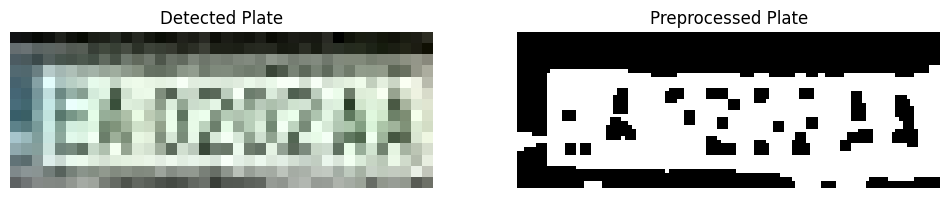

In [26]:
img = Image.open("car2 (1).jfif").convert("RGB")
img.save("/content/car2.jpg", "JPEG")

result = detect_plate_improved("/content/car2.jpg")

if result:
    print("Improved OCR:", result["plate"])

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(result["original"])
    plt.axis("off")
    plt.title("Detected Plate")

    plt.subplot(1, 2, 2)
    plt.imshow(result["processed"], cmap="gray")
    plt.axis("off")
    plt.title("Preprocessed Plate")

    plt.show()


image 1/1 /content/car2.jpg: 448x640 1 license_plate, 10.8ms
Speed: 3.1ms preprocess, 10.8ms inference, 1.9ms postprocess per image at shape (1, 3, 448, 640)


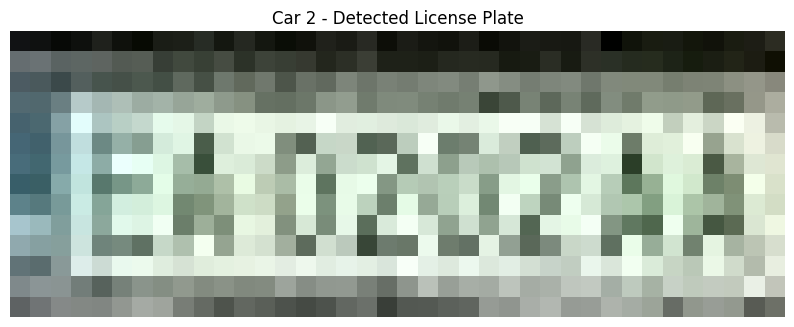

In [27]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("/content/car2.jpg")

results = plate_model("/content/car2.jpg")

box = results[0].boxes.xyxy[0].cpu().numpy()
x1, y1, x2, y2 = map(int, box)

plate_crop = image[y1:y2, x1:x2]
plate_rgb = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 4))
plt.imshow(plate_rgb)
plt.axis("off")
plt.title("Car 2 - Detected License Plate")
plt.show()

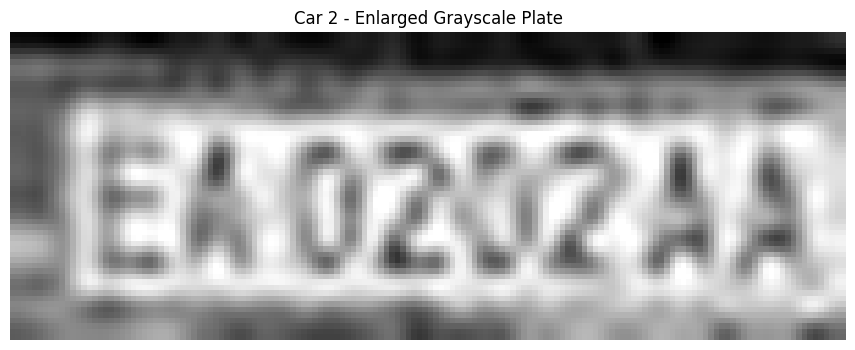

In [28]:
gray = cv2.cvtColor(plate_rgb, cv2.COLOR_RGB2GRAY)

gray = cv2.resize(
    gray,
    None,
    fx=4,
    fy=4,
    interpolation=cv2.INTER_CUBIC
)

plt.figure(figsize=(12, 4))
plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.title("Car 2 - Enlarged Grayscale Plate")
plt.show()

In [29]:
ocr_result = reader.readtext(gray)

print("OCR Result:")

for result in ocr_result:
    text = result[1]
    confidence = float(result[2])

    print("Text:", text)
    print("Confidence:", round(confidence, 2))

OCR Result:
Text: E0224
Confidence: 0.18


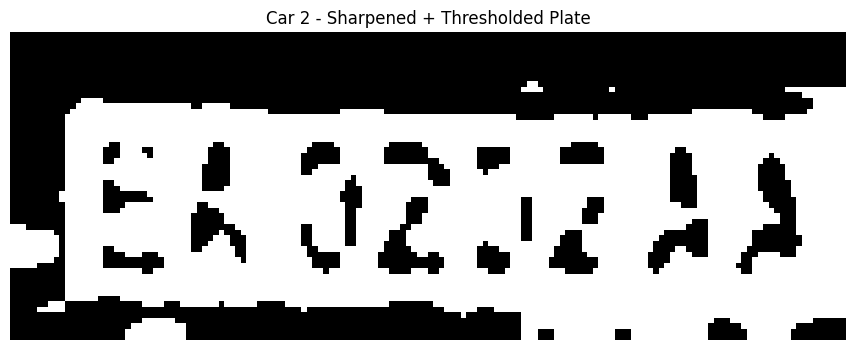

In [30]:
# Sharpen the grayscale image
blur = cv2.GaussianBlur(gray, (3, 3), 0)

sharp = cv2.addWeighted(
    gray,
    1.8,
    blur,
    -0.8,
    0
)

_, thresh = cv2.threshold(
    sharp,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.figure(figsize=(12, 4))
plt.imshow(thresh, cmap="gray")
plt.axis("off")
plt.title("Car 2 - Sharpened + Thresholded Plate")
plt.show()

In [31]:
ocr_result = reader.readtext(thresh)

print("OCR Result:")

for result in ocr_result:
    text = result[1]
    confidence = float(result[2])

    print("Text:", text)
    print("Confidence:", round(confidence, 2))

OCR Result:
Text: E83A
Confidence: 0.02


In [33]:
ocr_result = reader.readtext(
    gray,
    detail=1,
    paragraph=False,
    allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
)

print("OCR Result:")

for result in ocr_result:
    text = result[1]
    confidence = float(result[2])

    print("Text:", text)
    print("Confidence:", round(confidence, 2))

OCR Result:
Text: E0224
Confidence: 0.3


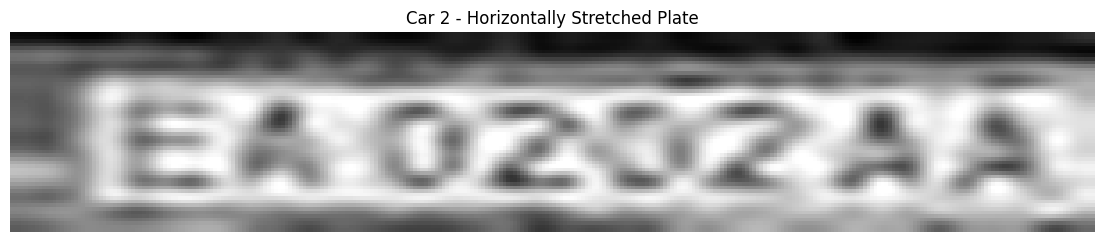

In [34]:
h, w = gray.shape

stretched = cv2.resize(
    gray,
    (w * 2, h),
    interpolation=cv2.INTER_CUBIC
)

plt.figure(figsize=(14, 4))
plt.imshow(stretched, cmap="gray")
plt.axis("off")
plt.title("Car 2 - Horizontally Stretched Plate")
plt.show()

In [35]:
ocr_result = reader.readtext(
    stretched,
    detail=1,
    paragraph=False,
    allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
)

print("OCR Result:")

for result in ocr_result:
    text = result[1]
    confidence = float(result[2])

    print("Text:", text)
    print("Confidence:", round(confidence, 2))

OCR Result:
Text: B027
Confidence: 0.19


In [36]:
ocr_result = reader.readtext(
    plate_rgb,
    detail=1,
    paragraph=False,
    allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
)

print("OCR Result:")

for result in ocr_result:
    text = result[1]
    confidence = float(result[2])

    print("Text:", text)
    print("Confidence:", round(confidence, 2))

OCR Result:
Text: EER02I24
Confidence: 0.05


In [37]:
img = Image.open("car3.jfif").convert("RGB")
img.save("/content/car3.jpg", "JPEG")

result = detect_plate("/content/car3.jpg")

if result:
    print("Detected Plate:", result["plate"])
    print("Confidence:", round(result["confidence"], 2))
else:
    print("No license plate detected.")


image 1/1 /content/car3.jpg: 512x640 1 license_plate, 7.4ms
Speed: 1.9ms preprocess, 7.4ms inference, 1.4ms postprocess per image at shape (1, 3, 512, 640)
Detected Plate: 06 572
Confidence: 1.0


In [38]:
img = Image.open("car4.jfif").convert("RGB")
img.save("/content/car4.jpg", "JPEG")

result = detect_plate("/content/car4.jpg")

if result:
    print("Detected Plate:", result["plate"])
    print("Confidence:", round(result["confidence"], 2))
else:
    print("No license plate detected.")


image 1/1 /content/car4.jpg: 384x640 1 license_plate, 11.8ms
Speed: 2.0ms preprocess, 11.8ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)
Detected Plate: 
Confidence: 0.31



image 1/1 /content/car4.jpg: 384x640 1 license_plate, 6.7ms
Speed: 1.5ms preprocess, 6.7ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


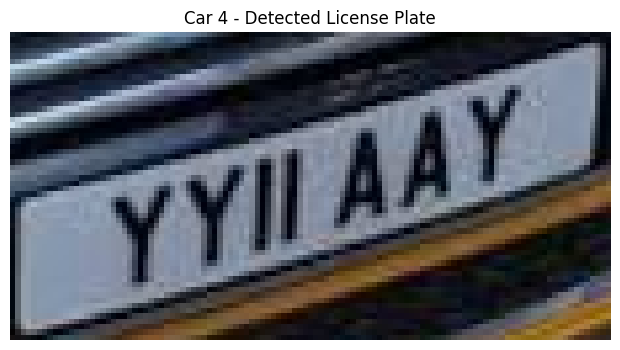

In [39]:
image = cv2.imread("/content/car4.jpg")

results = plate_model("/content/car4.jpg")

box = results[0].boxes.xyxy[0].cpu().numpy()
x1, y1, x2, y2 = map(int, box)

plate_crop = image[y1:y2, x1:x2]
plate_rgb = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 4))
plt.imshow(plate_rgb)
plt.axis("off")
plt.title("Car 4 - Detected License Plate")
plt.show()

In [40]:
ocr_result = reader.readtext(
    plate_rgb,
    detail=1,
    paragraph=False,
    allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
)

print("OCR Result:")

for result in ocr_result:
    text = result[1]
    confidence = float(result[2])

    print("Text:", text)
    print("Confidence:", round(confidence, 2))

OCR Result:
Text: AY
Confidence: 0.07
Text: YYI
Confidence: 0.35


In [41]:
img = Image.open("car5.jfif").convert("RGB")
img.save("/content/car5.jpg", "JPEG")

result = detect_plate("/content/car5.jpg")

if result:
    print("Detected Plate:", result["plate"])
    print("Confidence:", round(result["confidence"], 2))
else:
    print("No license plate detected.")


image 1/1 /content/car5.jpg: 512x640 1 license_plate, 7.4ms
Speed: 1.8ms preprocess, 7.4ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 640)
Detected Plate: 
Confidence: 0.3



image 1/1 /content/car5.jpg: 512x640 1 license_plate, 6.3ms
Speed: 2.6ms preprocess, 6.3ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 640)


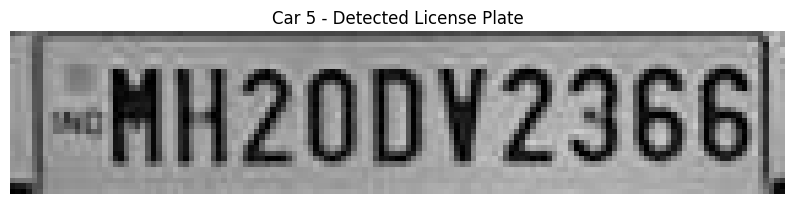

In [42]:
image = cv2.imread("/content/car5.jpg")

results = plate_model("/content/car5.jpg")

box = results[0].boxes.xyxy[0].cpu().numpy()
x1, y1, x2, y2 = map(int, box)

plate_crop = image[y1:y2, x1:x2]
plate_rgb = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 4))
plt.imshow(plate_rgb)
plt.axis("off")
plt.title("Car 5 - Detected License Plate")
plt.show()

In [43]:
ocr_result = reader.readtext(
    plate_rgb,
    detail=1,
    paragraph=False,
    allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
)

print("OCR Result:")

for result in ocr_result:
    text = result[1]
    confidence = float(result[2])

    print("Text:", text)
    print("Confidence:", round(confidence, 2))

OCR Result:
Text: HHZODV23661
Confidence: 0.33


In [44]:
def ANPR(image_path):
    results = plate_model(image_path)

    if len(results[0].boxes) == 0:
        return {
            "plate": None,
            "confidence": 0,
            "message": "No license plate detected"
        }

    image = cv2.imread(image_path)

    box = results[0].boxes.xyxy[0].cpu().numpy()
    x1, y1, x2, y2 = map(int, box)

    plate_crop = image[y1:y2, x1:x2]

    plate_rgb = cv2.cvtColor(
        plate_crop,
        cv2.COLOR_BGR2RGB
    )

    ocr_result = reader.readtext(
        plate_rgb,
        detail=1,
        paragraph=False,
        allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
    )

    detected_text = []

    for result in ocr_result:
        text = result[1]
        confidence = float(result[2])

        if confidence >= 0.30:
            detected_text.append(text)

    plate_text = " ".join(detected_text)

    if ocr_result:
        confidence = max(
            float(result[2])
            for result in ocr_result
        )
    else:
        confidence = 0

    return {
        "plate": plate_text,
        "confidence": confidence,
        "crop": plate_rgb
    }

print("ANPR function ready!")

ANPR function ready!



image 1/1 /content/car1.jpg: 352x640 1 license_plate, 8.2ms
Speed: 1.4ms preprocess, 8.2ms inference, 1.6ms postprocess per image at shape (1, 3, 352, 640)
Detected Plate: LEF 3503
Confidence: 0.93


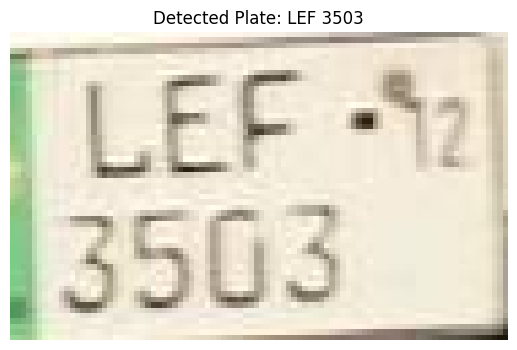

In [45]:
result = ANPR("/content/car1.jpg")

print("Detected Plate:", result["plate"])
print("Confidence:", round(result["confidence"], 2))

if result["plate"]:
    plt.figure(figsize=(10, 4))
    plt.imshow(result["crop"])
    plt.axis("off")
    plt.title(f"Detected Plate: {result['plate']}")
    plt.show()


image 1/1 /content/car3.jpg: 512x640 1 license_plate, 7.8ms
Speed: 2.4ms preprocess, 7.8ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 640)
Detected Plate: 06 572
Confidence: 1.0


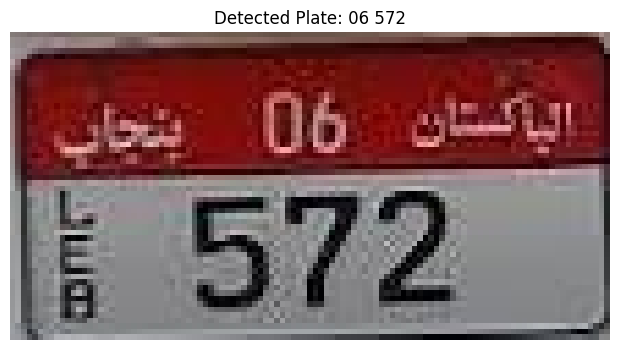

In [46]:
result = ANPR("/content/car3.jpg")

print("Detected Plate:", result["plate"])
print("Confidence:", round(result["confidence"], 2))

if result["plate"]:
    plt.figure(figsize=(10, 4))
    plt.imshow(result["crop"])
    plt.axis("off")
    plt.title(f"Detected Plate: {result['plate']}")
    plt.show()

In [47]:
test_images = [
    "/content/car1.jpg",
    "/content/car2.jpg",
    "/content/car3.jpg",
    "/content/car4.jpg",
    "/content/car5.jpg"
]

for image_path in test_images:
    print("\n==============================")
    print("Image:", image_path)

    result = ANPR(image_path)

    print("Detected Plate:", result["plate"])
    print("Confidence:", round(result["confidence"], 2))


Image: /content/car1.jpg

image 1/1 /content/car1.jpg: 352x640 1 license_plate, 11.8ms
Speed: 1.8ms preprocess, 11.8ms inference, 2.0ms postprocess per image at shape (1, 3, 352, 640)
Detected Plate: LEF 3503
Confidence: 0.93

Image: /content/car2.jpg

image 1/1 /content/car2.jpg: 448x640 1 license_plate, 6.8ms
Speed: 1.6ms preprocess, 6.8ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)
Detected Plate: 
Confidence: 0.05

Image: /content/car3.jpg

image 1/1 /content/car3.jpg: 512x640 1 license_plate, 6.8ms
Speed: 1.8ms preprocess, 6.8ms inference, 1.1ms postprocess per image at shape (1, 3, 512, 640)
Detected Plate: 06 572
Confidence: 1.0

Image: /content/car4.jpg

image 1/1 /content/car4.jpg: 384x640 1 license_plate, 6.4ms
Speed: 1.7ms preprocess, 6.4ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)
Detected Plate: YYI
Confidence: 0.35

Image: /content/car5.jpg

image 1/1 /content/car5.jpg: 512x640 1 license_plate, 6.8ms
Speed: 2.2ms preprocess, 6.

## Results

The ANPR system was tested on five vehicle images.

The YOLO model successfully detected a license plate region in all five test images. EasyOCR was then applied to the detected plate regions to recognize the characters.

Example recognized results included:

* Car 1: `LEF 3503`
* Car 3: `06 572`

Some other images produced low-confidence or unreliable OCR results.

## Limitations

The OCR performance depends on several factors:

* Image resolution
* License plate size
* Lighting conditions
* Camera angle
* Blur and image quality
* Visibility of characters
* Different license plate formats

A low OCR confidence score should not be considered a confirmed license plate number.

For a production-level ANPR system, a larger and more diverse dataset, better preprocessing, and model fine-tuning would be required.


## Conclusion

In this project, a basic Automatic Number Plate Recognition (ANPR) system was developed using YOLO and EasyOCR.

The system can detect a license plate from a vehicle image, crop the detected region, and attempt to recognize the plate characters using OCR.

The project demonstrates the complete computer vision pipeline:

**Vehicle Image → License Plate Detection → Plate Cropping → OCR → Detected Text**

The reusable `ANPR()` function makes it possible to process different vehicle images using the same pipeline.

This project provides a foundation for building a production-level ANPR application that can later be integrated with a web API and frontend application.
